In [1]:
!pip install thop
!pip install ptflops

In [2]:
import requests
from PIL import Image
from io import BytesIO
import yaml
import torch
import torch.nn as nn
import torchvision.transforms as T
import numpy as np

In [3]:
import glob
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [5]:
device

'cuda'

In [ ]:
#DATA_PATH = "/gdrive/MyDrive/Super_Resolution/Data/Test_images_2023"
#DATA_PATH = "/gdrive/MyDrive/SR_seeds/Test_images_2023"
DATA_PATH = "/content/gdrive/MyDrive/SR_seeds/Grains_(Pasynkov)"

In [ ]:
all_orig_imgs = []
all_lr_imgs = []
for i in range(2651, 4501):
  img = Image.open(DATA_PATH + f"/grain_{i}.png").convert("RGB")

  all_orig_imgs.append(img)

  w, h = img.size

  lr_img = img.resize((int(w*1), int(h*1)))
  all_lr_imgs.append(lr_img)

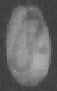

In [ ]:
all_orig_imgs[6]

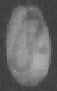

In [ ]:
all_lr_imgs[6]

In [6]:
all_sr_imgs = []

In [7]:
transform = T.ToTensor()
to_pil = T.ToPILImage()

# DASR

In [8]:
!git clone https://github.com/csjliang/DASR
%cd DASR
!pip install -r requirements.txt
!python setup.py develop

Cloning into 'DASR'...
remote: Enumerating objects: 149, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 149 (delta 11), reused 6 (delta 6), pack-reused 123 (from 1)
Receiving objects: 100% (149/149), 797.55 KiB | 27.50 MiB/s, done.
Resolving deltas: 100% (38/38), done.
/content/DASR
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 146.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 26.6 MB/s eta 0:00:00
/usr/local/lib/python3.12/dist-packages/setuptools/__init__.py:94: _DeprecatedInstaller: setuptools.installer and fetch_build_eggs are deprecated.
!!

        ********************************************************************************
        Requirements should be satisfied by a PEP 517 installer.
        If you are usin

In [9]:
!mkdir -p /content/DASR/pretrained_models

!cp /content/gdrive/MyDrive/SR_seeds/net_g.pth /content/DASR/pretrained_models/
!cp /content/gdrive/MyDrive/SR_seeds/net_p.pth /content/DASR/pretrained_models/

In [ ]:
!find /content/ -name "net_g.pth"

/content/gdrive/MyDrive/SR_seeds/net_g.pth
/content/DASR/pretrained_models/net_g.pth


In [ ]:
!find /content/DASR -name "test.py"

/content/DASR/dasr/test.py
/content/DASR/basicsr/test.py


In [ ]:
!find -name "test_DASR.yml"

./options/test/DASR/test_DASR.yml


In [10]:
!mkdir -p /content/DASR/test_seeds

In [ ]:
for i, img in enumerate(all_lr_imgs):
    img.save(f'/content/DASR/test_seeds/img_{i}.png')

NameError: name 'all_lr_imgs' is not defined

In [11]:
config_path = '/content/DASR/options/test/DASR/test_DASR.yml'

In [12]:
with open(config_path, 'r') as f:
    cfg = yaml.safe_load(f)

In [ ]:
cfg = {'name': 'DASR',
  'model_type': 'SRGANDynamicModel',
  'scale': 4,
  'num_gpu': 1,
  'manual_seed': 0,
  'num_networks': 5,
  'datasets':{
    'test': {
            'name': 'TestGrainImages',
            'type': 'SingleImageDataset',
            'dataroot_lq': '/content/DASR/test_seeds',
            'io_backend': {'type': 'disk'}
        }
},
  "network_g":{
    'type': 'MSRResNetDynamic',
    'num_in_ch': 3,
    'num_out_ch': 3,
    'num_feat': 64,
    'num_block': 16,
    'num_models': 5,
    'upscale': 4
},
  'network_p':{
    'type': 'Degradation_Predictor',
    'in_nc': 3,
    'nf': 64,
    'num_params': 33,
    'num_networks': 5
},
  'path':{
    'pretrain_network_g': '/content/DASR/pretrained_models/net_g.pth',
    'pretrain_network_p': '/content/DASR/pretrained_models/net_p.pth',
    'param_key_g': None,
    'strict_load_g': True,
    'results_root': '/content/DASR/DASR/DASR/results/DASR',
    'log': '/content/DASR/DASR/DASR/results/DASR',
    'visualization': '/content/DASR/DASR/DASR/results/DASR/visualization'
},
  'val':{
    'save_img': True,
    'suffix': None
},
  'is_train': False,
  'auto_resume': False,
  'dist': False,
  'rank': 0,
  'world_size': 1
}

In [ ]:
config_path = '/content/DASR/my_test_config.yml'

with open(config_path, 'w') as f:
    yaml.dump(cfg, f)

In [ ]:
!python basicsr/test.py -opt /content/DASR/my_test_config.yml

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Disable distributed.
2026-04-19 11:52:23,453 INFO: 
                ____                _       _____  ____
               / __ ) ____ _ _____ (_)_____/ ___/ / __ \
              / __  |/ __ `// ___// // ___/\__ \ / /_/ /
             / /_/ // /_/ /(__  )/ // /__ ___/ // _, _/
            /_____/ \__,_//____//_/ \___//____//_/ |_|
     ______                   __   __                 __      __
    / ____/____   ____   ____/ /  / /   __  __ _____ / /__   / /
   / / __ / __ \ / __ \ / __  /  / /   / / / // ___// //_/  / /
  / /_/ // /_/ // /_/ // /_/ /  / /___/ /_/ // /__ / /<    /_/
  \____/ \____/ \____/ \____/  /_____/\____/ \___//_/|_|  (_)
    
Version Information: 
	BasicSR: 1.3.3.10
	PyTorch: 2.10.0+cu128
	Tor

In [ ]:
!find -name img_0_DASR.png

In [18]:
SAVE_PATH = "/content/gdrive/MyDrive/SR_seeds/DASR_(Pasynkov)/"
import os
os.makedirs(SAVE_PATH, exist_ok=True)

In [ ]:
for i in range(0, 1850):
  sr_path = f'./results/DASR/visualization/TestGrainImages/img_{i}_DASR.png'
  upscaled_image = Image.open(sr_path).convert("RGB")
  filename = f"{str(i+2650+1).zfill(4)}.png"  # 0001.png, 0002.png ...
  upscaled_image.save(os.path.join(SAVE_PATH, filename))

# Evaluation

In [13]:
EVALUATION_LR_PATH = "/content/gdrive/MyDrive/SR_seeds/Evaluation/LR/"
EVALUATION_HR_PATH = "/content/gdrive/MyDrive/SR_seeds/Evaluation/HR/"

In [14]:
lr_test = glob.glob(EVALUATION_LR_PATH + '*')
hr_test = glob.glob(EVALUATION_HR_PATH + '*')

In [15]:
hr_test

['/content/gdrive/MyDrive/SR_seeds/Evaluation/HR/hr_img_1.png',
 '/content/gdrive/MyDrive/SR_seeds/Evaluation/HR/hr_img_2.png',
 '/content/gdrive/MyDrive/SR_seeds/Evaluation/HR/hr_img_3.png',
 '/content/gdrive/MyDrive/SR_seeds/Evaluation/HR/hr_img_4.png',
 '/content/gdrive/MyDrive/SR_seeds/Evaluation/HR/hr_img_5.png',
 '/content/gdrive/MyDrive/SR_seeds/Evaluation/HR/hr_img_6.png',
 '/content/gdrive/MyDrive/SR_seeds/Evaluation/HR/hr_img_7.png']

In [16]:
all_lr_imgs = []
all_hr_imgs = []
for i in range(len(lr_test)):
  #lr_img = Image.open(lr_test[i]).convert("RGB").resize((64, 64))
  lr_img = Image.open(lr_test[i]).convert("RGB")
  hr_img = Image.open(hr_test[i]).convert("RGB")

  all_lr_imgs.append(lr_img)
  all_hr_imgs.append(hr_img)

In [19]:
os.makedirs('/content/DASR/eval_seeds/', exist_ok=True)
os.makedirs('/content/DASR/DASR/DASR/results/DASR/visualization/eval', exist_ok=True)
os.makedirs('/content/DASR/DASR/DASR/results/DASR/eval', exist_ok=True)


In [47]:
for i in range(7):
    all_lr_imgs[i].save(f'/content/DASR/eval_seeds/img_{i}.png')

In [48]:
cfg = {'name': 'DASR',
  'model_type': 'SRGANDynamicModel',
  'scale': 4,
  'num_gpu': 1,
  'manual_seed': 0,
  'num_networks': 5,
  'datasets':{
    'test': {
            'name': 'EvalGrainImages',
            'type': 'SingleImageDataset',
            'dataroot_lq': '/content/DASR/eval_seeds',
            'io_backend': {'type': 'disk'}
        }
},
  "network_g":{
    'type': 'MSRResNetDynamic',
    'num_in_ch': 3,
    'num_out_ch': 3,
    'num_feat': 64,
    'num_block': 16,
    'num_models': 5,
    'upscale': 4
},
  'network_p':{
    'type': 'Degradation_Predictor',
    'in_nc': 3,
    'nf': 64,
    'num_params': 33,
    'num_networks': 5
},
  'path':{
    'pretrain_network_g': '/content/DASR/pretrained_models/net_g.pth',
    'pretrain_network_p': '/content/DASR/pretrained_models/net_p.pth',
    'param_key_g': None,
    'strict_load_g': True,
    'results_root': '/content/DASR/DASR/DASR/results/DASR/eval',
    'log': '/content/DASR/DASR/DASR/results/DASR/eval',
    'visualization': '/content/DASR/DASR/DASR/results/DASR/visualization/eval'
},
  'val':{
    'save_img': True,
    'suffix': None
},
  'is_train': False,
  'auto_resume': False,
  'dist': False,
  'rank': 0,
  'world_size': 1
}

In [49]:
config_path = '/content/DASR/my_test_config.yml'

with open(config_path, 'w') as f:
    yaml.dump(cfg, f)

In [50]:
!python basicsr/test.py -opt /content/DASR/my_test_config.yml

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Disable distributed.
Path already exists. Rename it to /content/DASR/results/DASR_archived_20260504_235938
2026-05-04 23:59:38,162 INFO: 
                ____                _       _____  ____
               / __ ) ____ _ _____ (_)_____/ ___/ / __ \
              / __  |/ __ `// ___// // ___/\__ \ / /_/ /
             / /_/ // /_/ /(__  )/ // /__ ___/ // _, _/
            /_____/ \__,_//____//_/ \___//____//_/ |_|
     ______                   __   __                 __      __
    / ____/____   ____   ____/ /  / /   __  __ _____ / /__   / /
   / / __ / __ \ / __ \ / __  /  / /   / / / // ___// //_/  / /
  / /_/ // /_/ // /_/ // /_/ /  / /___/ /_/ // /__ / /<    /_/
  \____/ \____/ \____/ \____/  /_____/\____/ \___

In [51]:
!find /content/DASR/results/DASR/visualization

/content/DASR/results/DASR/visualization
/content/DASR/results/DASR/visualization/EvalGrainImages
/content/DASR/results/DASR/visualization/EvalGrainImages/img_2_DASR.png
/content/DASR/results/DASR/visualization/EvalGrainImages/img_3_DASR.png
/content/DASR/results/DASR/visualization/EvalGrainImages/img_0_DASR.png
/content/DASR/results/DASR/visualization/EvalGrainImages/img_4_DASR.png
/content/DASR/results/DASR/visualization/EvalGrainImages/img_1_DASR.png
/content/DASR/results/DASR/visualization/EvalGrainImages/img_6_DASR.png
/content/DASR/results/DASR/visualization/EvalGrainImages/img_5_DASR.png


In [52]:
SAVE_PATH = "/content/gdrive/MyDrive/SR_seeds/Evaluation/DASR/"

In [53]:
all_sr_imgs = []
for i in range(0, 7):
  sr_path = f'/content/DASR/results/DASR/visualization/EvalGrainImages/img_{i}_DASR.png'
  upscaled_image = Image.open(sr_path).convert("RGB")
  all_sr_imgs.append(upscaled_image)
  filename = f"{str(i+1).zfill(4)}.png"  # 0001.png, 0002.png ...
  upscaled_image.save(os.path.join(SAVE_PATH, filename))

In [54]:
all_lr_imgs

[<PIL.Image.Image image mode=RGB size=50x82>,
 <PIL.Image.Image image mode=RGB size=54x102>,
 <PIL.Image.Image image mode=RGB size=56x78>,
 <PIL.Image.Image image mode=RGB size=48x90>,
 <PIL.Image.Image image mode=RGB size=45x84>,
 <PIL.Image.Image image mode=RGB size=57x85>,
 <PIL.Image.Image image mode=RGB size=65x98>]

In [55]:
all_hr_imgs

[<PIL.Image.Image image mode=RGB size=258x390>,
 <PIL.Image.Image image mode=RGB size=179x334>,
 <PIL.Image.Image image mode=RGB size=225x310>,
 <PIL.Image.Image image mode=RGB size=190x359>,
 <PIL.Image.Image image mode=RGB size=216x408>,
 <PIL.Image.Image image mode=RGB size=198x327>,
 <PIL.Image.Image image mode=RGB size=226x341>]

In [56]:
all_sr_imgs

[<PIL.Image.Image image mode=RGB size=200x328>,
 <PIL.Image.Image image mode=RGB size=216x408>,
 <PIL.Image.Image image mode=RGB size=224x312>,
 <PIL.Image.Image image mode=RGB size=192x360>,
 <PIL.Image.Image image mode=RGB size=180x336>,
 <PIL.Image.Image image mode=RGB size=228x340>,
 <PIL.Image.Image image mode=RGB size=260x392>]

In [75]:
import torch.nn.functional as F
from math import log10
from skimage.metrics import structural_similarity as ssim
import numpy as np

psnr_list = []
ssim_list = []

In [31]:
def compute_psnr(sr, hr):
    mse = F.mse_loss(sr, hr)
    if mse == 0:
        return 100
    return 10 * log10(1.0 / mse.item())


def compute_ssim(sr, hr):
    sr = sr.permute(1, 2, 0).cpu().numpy()
    hr = hr.permute(1, 2, 0).cpu().numpy()

    return ssim(sr, hr, channel_axis=2, data_range=1.0)

In [58]:
sr_results = []

In [33]:
def match_size(sr, hr):
    """
    HR to the size of SR through bilinear resize
    """
    sr_h, sr_w = sr.shape[-2], sr.shape[-1]
    hr = F.interpolate(hr.unsqueeze(0), size=(sr_h, sr_w), mode="bilinear", align_corners=False)
    return hr.squeeze(0)

In [71]:
all_sr_imgs[0], all_sr_imgs[6] = all_sr_imgs[6], all_sr_imgs[0]
all_lr_imgs[0], all_lr_imgs[6] = all_lr_imgs[6], all_lr_imgs[0]

all_sr_imgs[1], all_sr_imgs[4] = all_sr_imgs[4], all_sr_imgs[1]
all_lr_imgs[1], all_lr_imgs[4] = all_lr_imgs[4], all_lr_imgs[1]

all_sr_imgs[5], all_sr_imgs[6] = all_sr_imgs[6], all_sr_imgs[5]
all_lr_imgs[5], all_lr_imgs[6] = all_lr_imgs[6], all_lr_imgs[5]

In [76]:
for i in range(0, 7):
    lr_img = all_lr_imgs[i]
    hr_img = all_hr_imgs[i]
    sr_img = all_sr_imgs[i]

    # ===== SR tensor =====
    sr_tensor = transform(sr_img.convert("RGB"))

    # ===== HR tensor =====
    hr_tensor = transform(hr_img.convert("RGB"))

    # ===== ALIGN SIZE (CRITICAL) =====
    if hr_tensor.shape != sr_tensor.shape:
        hr_tensor = match_size(sr_tensor, hr_tensor)

    # ===== METRICS =====
    psnr_val = compute_psnr(sr_tensor, hr_tensor)
    ssim_val = compute_ssim(sr_tensor, hr_tensor)

    psnr_list.append(psnr_val)
    ssim_list.append(ssim_val)

    print(f"[{i+1}] PSNR: {psnr_val:.3f} | SSIM: {ssim_val:.4f}")

[1] PSNR: 35.802 | SSIM: 0.8655
[2] PSNR: 34.552 | SSIM: 0.8357
[3] PSNR: 36.051 | SSIM: 0.8546
[4] PSNR: 34.650 | SSIM: 0.8248
[5] PSNR: 32.473 | SSIM: 0.7529
[6] PSNR: 34.987 | SSIM: 0.8458
[7] PSNR: 34.199 | SSIM: 0.8249


In [77]:
print("\n========== FINAL ==========")
print(f"Mean PSNR: {np.mean(psnr_list):.3f}")
print(f"Mean SSIM: {np.mean(ssim_list):.4f}")


========== FINAL ==========
Mean PSNR: 34.673
Mean SSIM: 0.8292


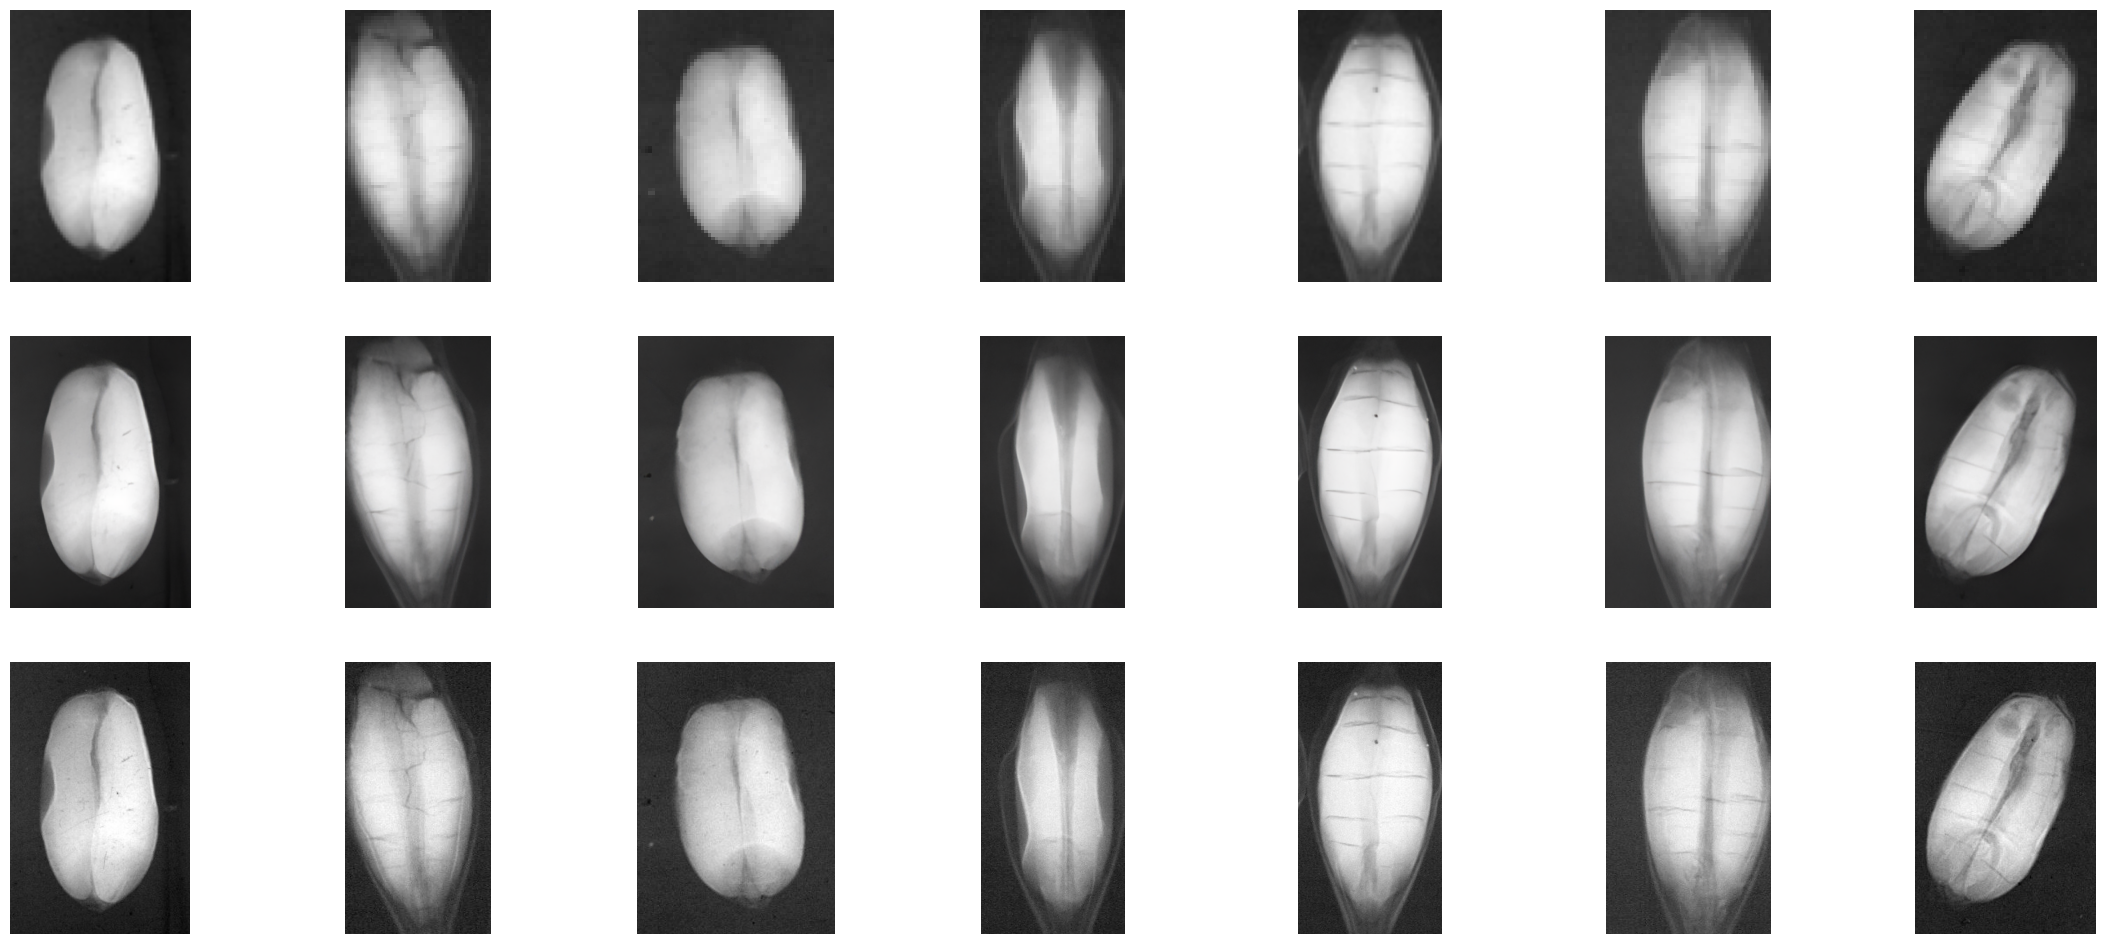

In [78]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(28, 12))
for i in range(len(all_sr_imgs)):
    ax = fig.add_subplot(3, 7, 1+i)
    ax.imshow(all_lr_imgs[i])
    ax.axis("off")

    ax = fig.add_subplot(3, 7, 1+i+7)
    ax.imshow(all_sr_imgs[i])
    ax.axis("off")

    ax = fig.add_subplot(3, 7, 1+i+14)
    ax.imshow(all_hr_imgs[i])
    ax.axis("off")